<a href="https://colab.research.google.com/github/Balajivallepu/Data_Mining_Big_Data_Analytics/blob/main/DMBDA_project_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

df = pd.read_csv("loan_data.csv")

df.head()

,Text,Income,Credit_Score,Loan_Amount,DTI_Ratio,Employment_Status,Approval
0,I need a loan to pay for an international vaca...,26556,581,8314,79.26,employed,Rejected
1,I want to make home improvements like installi...,197392,389,111604,22.14,employed,Rejected
2,"I need a loan for home renovation, including a...",44561,523,34118,45.44,employed,Rejected
3,I need funds to buy new furniture and applianc...,190363,729,118757,10.22,unemployed,Rejected
4,I need a loan to start a small business.,61853,732,19210,44.13,employed,Approved


In [2]:
df.isnull().sum()

,0
Text,0
Income,0
Credit_Score,0
Loan_Amount,0
DTI_Ratio,0
Employment_Status,0
Approval,0


In [3]:
df.drop_duplicates(inplace=True)

In [4]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['Approval'] = encoder.fit_transform(df['Approval'])

df['Employment_Status'] = encoder.fit_transform(df['Employment_Status'])

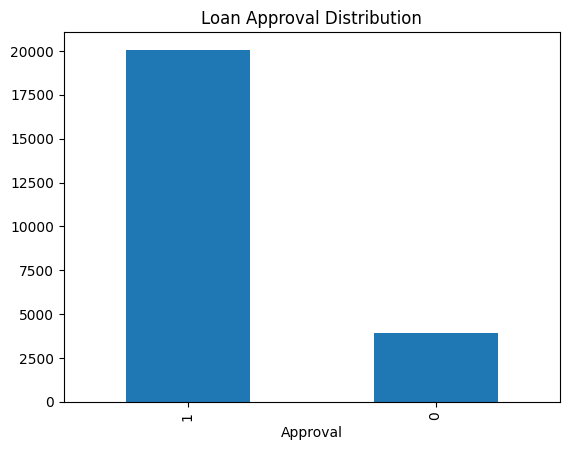

In [5]:
import matplotlib.pyplot as plt

df['Approval'].value_counts().plot(kind='bar')

plt.title("Loan Approval Distribution")
plt.show()

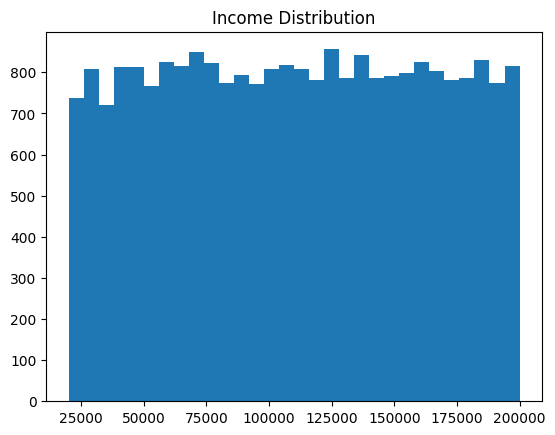

In [6]:
plt.hist(df['Income'], bins=30)

plt.title("Income Distribution")

plt.show()

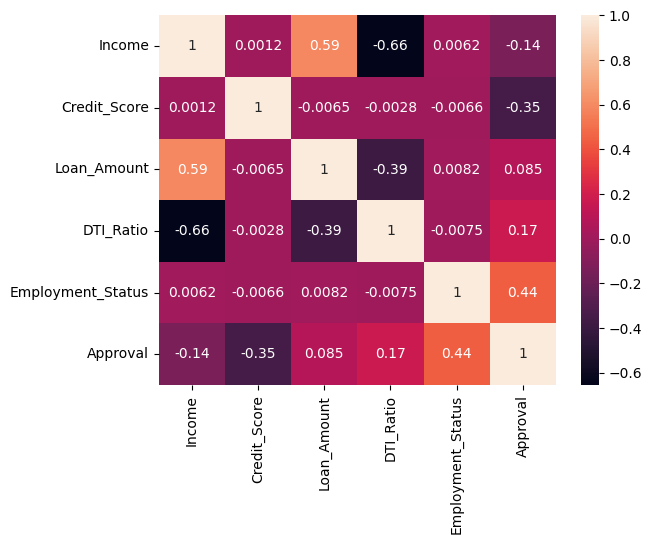

In [7]:
import seaborn as sns

sns.heatmap(df.corr(numeric_only=True), annot=True)

plt.show()

In [8]:
from sklearn.model_selection import train_test_split

X = df[['Income',
        'Credit_Score',
        'Loan_Amount',
        'DTI_Ratio']]

y = df['Approval']

X_train,X_test,y_train,y_test=train_test_split(
X,y,test_size=0.2,random_state=42)

In [9]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

model.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [10]:
y_pred = model.predict(X_test)

In [11]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test,y_pred)

print("Accuracy:",accuracy)

Accuracy: 0.8354166666666667


In [12]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,y_pred)

print(cm)

[[ 358  395]
 [ 395 3652]]


In [13]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.48      0.48      0.48       753
           1       0.90      0.90      0.90      4047

    accuracy                           0.84      4800
   macro avg       0.69      0.69      0.69      4800
weighted avg       0.84      0.84      0.84      4800

